<a href="https://colab.research.google.com/github/carlosyugsi332-droid/Deberes-/blob/main/Ciclo%20Otto%20c.y.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

             RESULTADOS
Eficiencia térmica (η_th): 60.96%
Tasa de suministro de calor (Q_dot_in): 147.64 kW


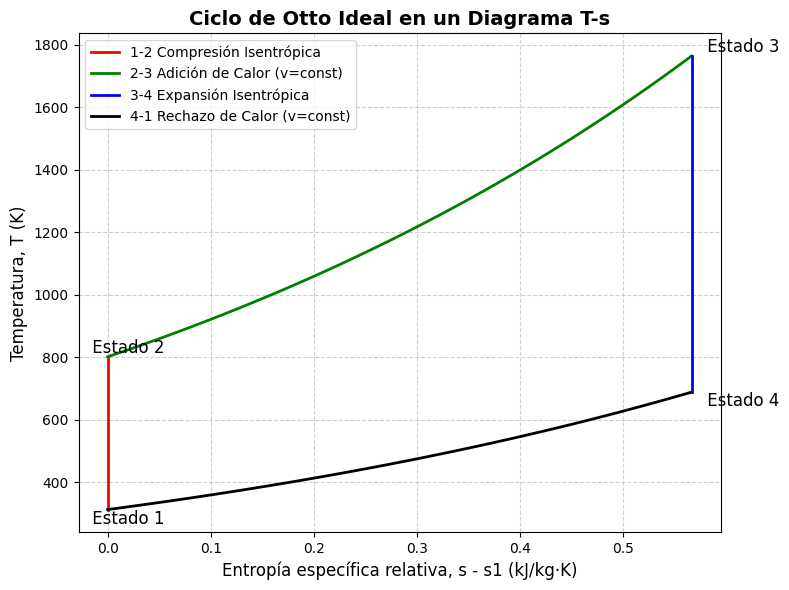

In [1]:

# -*- coding: utf-8 -*-
"""
Resolución del Ejercicio 9-33: Ciclo Ideal de Otto
"""

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DATOS DEL PROBLEMA
# ==========================================
r = 10.5        # Relación de compresión
P1 = 90.0       # Presión de entrada (kPa)
T1_C = 40.0     # Temperatura de entrada (°C)
T1 = T1_C + 273.15  # Temperatura de entrada (K)
W_net_out = 90.0 # Potencia neta de salida (kW)

# Propiedades del aire a temperatura ambiente (300 K)
k = 1.4         # Relación de calores específicos (Cp/Cv)
Cv = 0.718      # Calor específico a volumen constante (kJ/kg·K)
R = 0.287       # Constante individual del gas para el aire (kJ/kg·K)

# ==========================================
# 2. CÁLCULOS TERMODINÁMICOS
# ==========================================
# Eficiencia térmica del ciclo Otto ideal:
# eta_th = 1 - (1 / r^(k-1))
eta_th = 1 - (1 / (r**(k - 1)))

# Tasa de suministro de calor requerida (Q_in_dot):
# eta_th = W_net_out / Q_in_dot  =>  Q_in_dot = W_net_out / eta_th
Q_in_dot = W_net_out / eta_th

print("="*40)
print("             RESULTADOS")
print("="*40)
print(f"Eficiencia térmica (η_th): {eta_th * 100:.2f}%")
print(f"Tasa de suministro de calor (Q_dot_in): {Q_in_dot:.2f} kW")
print("="*40)

# ==========================================
# 3. CONSTRUCCIÓN DE LOS ESTADOS PARA EL DIAGRAMA T-s
# ==========================================
# Para trazar un ciclo completo con un diagrama T-s realista,
# asumiremos un calentamiento típico de T2 a T3 (ej. duplicando la temperatura en el quemador).
T2 = T1 * (r**(k - 1))
T3 = T2 * 2.2  # Valor asumido con fines puramente ilustrativos del ciclo
T4 = T3 / (r**(k - 1))

# Entropías de referencia (s = Cv * ln(T/T1) + R * ln(v/v1) -> tomamos s1 = 0 como referencia arbitraria)
# Para el gas ideal, ds = Cv*ln(T2/T1) + R*ln(v2/v1)
s1 = 0.0
s2 = s1  # Proceso 1-2 es isentrópico (s2 = s1)

# Proceso 2-3 (Volumen constante, v3 = v2): s3 - s2 = Cv * ln(T3/T2)
s3 = s2 + Cv * np.log(T3 / T2)
s4 = s3  # Proceso 3-4 es isentrópico (s4 = s3)

# Generación de curvas para los procesos no isentrópicos (Volumen constante)
# Proceso 2-3 (Isocórico): v = v2 = v3
T_23 = np.linspace(T2, T3, 100)
s_23 = s2 + Cv * np.log(T_23 / T2)

# Proceso 4-1 (Isocórico): v = v4 = v1
T_41 = np.linspace(T1, T4, 100)
s_41 = s1 + Cv * np.log(T_41 / T1)

# ==========================================
# 4. GRÁFICA DEL DIAGRAMA T-s
# ==========================================
plt.figure(figsize=(8, 6))

# Líneas isentrópicas (verticales)
plt.plot([s1, s2], [T1, T2], 'r-', linewidth=2, label='1-2 Compresión Isentrópica')
# Curva a Volumen Constante (Adición de calor)
plt.plot(s_23, T_23, 'g-', linewidth=2, label='2-3 Adición de Calor (v=const)')
# Línea isentrópica (vertical)
plt.plot([s3, s4], [T3, T4], 'b-', linewidth=2, label='3-4 Expansión Isentrópica')
# Curva a Volumen Constante (Rechazo de calor)
plt.plot(s_41, T_41, 'k-', linewidth=2, label='4-1 Rechazo de Calor (v=const)')

# Etiquetas de los estados
plt.text(s1 - 0.02, T1, ' Estado 1', fontsize=12, verticalalignment='top')
plt.text(s2 - 0.02, T2, ' Estado 2', fontsize=12, verticalalignment='bottom')
plt.text(s3 + 0.01, T3, ' Estado 3', fontsize=12, verticalalignment='bottom')
plt.text(s4 + 0.01, T4, ' Estado 4', fontsize=12, verticalalignment='top')

plt.title('Ciclo de Otto Ideal en un Diagrama T-s', fontsize=14, fontweight='bold')
plt.xlabel('Entropía específica relativa, s - s1 (kJ/kg·K)', fontsize=12)
plt.ylabel('Temperatura, T (K)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.tight_layout()
plt.show()